# EDA & 데이터 전처리

## major type / major1_1 / major1_2
- major1_1과 major1_2를 보고 major type을 단일 전공, 복수 전공, 미입력으로 나눔
- major1_1과 major1_2의 nan값은 미입력으로 변환함

In [ ]:
# '미입력'으로 채우기 전에 수행
train['is_major1_1_nan'] = train['major1_1'].isna().astype(int)
test['is_major1_1_nan'] = test['major1_1'].isna().astype(int)

In [ ]:
# '미입력'으로 채우기 전에 수행
train['is_major1_2_nan'] = train['major1_2'].isna().astype(int)
test['is_major1_2_nan'] = test['major1_2'].isna().astype(int)

In [ ]:
# major_type의 NaN을 '미입력'으로 채우기
train['major type'] = train['major type'].fillna('미입력')
test['major type'] = test['major type'].fillna('미입력')
cols = ['major1_1', 'major1_2']
train[cols] = train[cols].fillna('미입력')
test[cols] = test[cols].fillna('미입력')

print(train['major type'].value_counts(dropna=False))
print(test['major type'].value_counts(dropna=False))

major type
단일 전공                      419
복수 전공 ( 다중전공, 이중전공 포함 )    309
미입력                         20
Name: count, dtype: int64
major type
복수 전공 ( 다중전공, 이중전공 포함 )    631
단일 전공                      110
미입력                         73
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_27796\900728092.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=time_analysis, x='time_input', y='mean', ax=ax1, palette='Blues_d', alpha=0.7)
c:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\User\anaconda3\Lib\site-packages\IPython\c

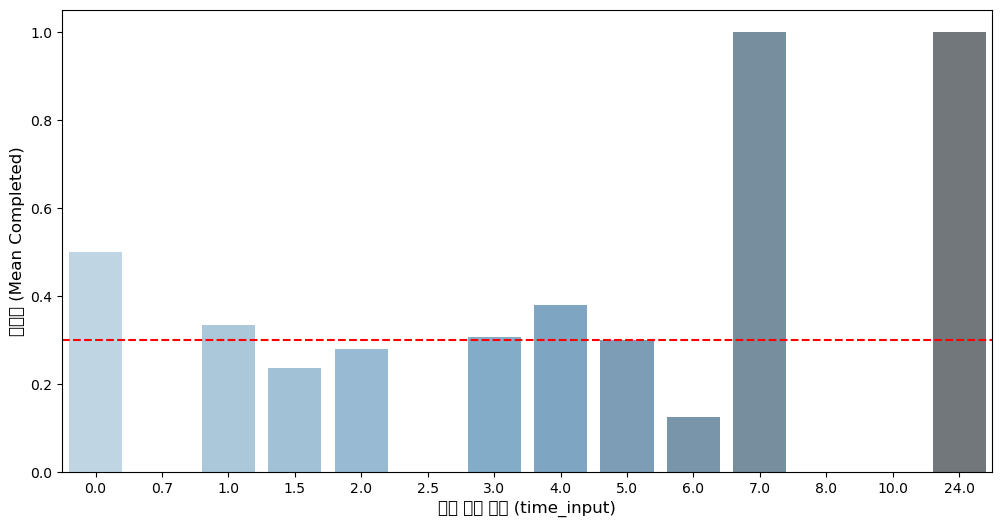

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시간대별 수료율과 응답자 수(count) 계산
time_analysis = train.groupby('time_input')['completed'].agg(['mean', 'count']).reset_index()

# 2. 시각화 설정
fig, ax1 = plt.subplots(figsize=(12, 6))

# 수료율 막대 그래프 (왼쪽 축)
sns.barplot(data=time_analysis, x='time_input', y='mean', ax=ax1, palette='Blues_d', alpha=0.7)
ax1.set_ylabel('수료율 (Mean Completed)', fontsize=12)
ax1.set_xlabel('주당 투자 시간 (time_input)', fontsize=12)
ax1.axhline(train['completed'].mean(), color='red', linestyle='--', label='전체 평균 수료율')
plt.show()

In [ ]:
# IT 관련 직무 리스트 (데이터 A~D + 개발 E + 기획 G)
it_job_cols = ['desired_job_A', 'desired_job_B', 'desired_job_C', 'desired_job_D', 'desired_job_E', 'desired_job_G']
test['is_it_job'] = test[it_job_cols].max(axis=1)
train['is_it_job'] = train[it_job_cols].max(axis=1)

# 1. 데이터 특화 일치 (가장 강력한 수료 의지)
data_job_cols = ['desired_job_A', 'desired_job_B', 'desired_job_C', 'desired_job_D']
test['match_data_specialist'] = ((test['is_major_it'] == 1) & (test[data_job_cols].max(axis=1) == 1)).astype(int)
train['match_data_specialist'] = ((train['is_major_it'] == 1) & (train[data_job_cols].max(axis=1) == 1)).astype(int)

# 2. IT 일반 일치 (개발/기획 포함 IT 전반)
train['match_it_general'] = ((train['is_major_it'] == 1) & (train['is_it_job'] == 1)).astype(int)
test['match_it_general'] = ((test['is_major_it'] == 1) & (test['is_it_job'] == 1)).astype(int)

# encoding

## 원핫인코딩

In [ ]:
def encode_categorical_features(train_df, test_df):
    # 1. 원핫인코딩을 적용할 컬럼 리스트
    cat_cols = [
          
        
         'incumbents_company_level',
    ]
    
    for col in cat_cols:
        if col in train_df.columns:
            # 결측치를 미리 'Unknown'으로 채워 인코딩에서 누락되지 않게 함
            train_df[col] = train_df[col].fillna('Unknown').astype(str)
            test_df[col] = test_df[col].fillna('Unknown').astype(str)
            
            # 각 데이터프레임별로 덤미 변수 생성
            train_dummies = pd.get_dummies(train_df[col], prefix=col)
            test_dummies = pd.get_dummies(test_df[col], prefix=col)
            
            # [핵심] Test 데이터의 컬럼 구성을 Train과 동일하게 맞춤
            # Train에만 있는 컬럼은 Test에 0으로 추가되고, Test에만 있는 컬럼은 삭제됨
            test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)
            
            # 기존 데이터프레임에 합치기
            train_df = pd.concat([train_df, train_dummies], axis=1)
            test_df = pd.concat([test_df, test_dummies], axis=1)
            
            # 원본 문자열 컬럼 삭제
            train_df = train_df.drop(columns=[col])
            test_df = test_df.drop(columns=[col])
            
    return train_df, test_df

# --- 실제 적용 ---
train, test = encode_categorical_features(train, test)

# 결과 확인 (컬럼 수가 늘어났는지 확인)
print(f"Train columns: {len(train.columns)}")
print(f"Test columns: {len(test.columns)}")


Train columns: 220
Test columns: 219
